In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
import warnings
warnings.filterwarnings('ignore')

# Load dữ liệu
train_data = pd.read_csv('house-prices-advanced-regression-techniques/train.csv')
test_data = pd.read_csv('house-prices-advanced-regression-techniques/test.csv')

print(f"Train shape: {train_data.shape}")
print(f"Test shape: {test_data.shape}")
print(f"\nTarget variable statistics:")
print(train_data['SalePrice'].describe())

# Hiển thị thông tin cơ bản về dữ liệu
train_data.head()


Train shape: (1460, 81)
Test shape: (1459, 80)

Target variable statistics:
count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [2]:
# Data Preprocessing - Xử lý dữ liệu thiếu và feature engineering

# Kết hợp train và test để preprocessing nhất quán
all_data = pd.concat([train_data.drop('SalePrice', axis=1), test_data], ignore_index=True)

# Xử lý missing values
def handle_missing_values(df):
    """
    Xử lý các giá trị thiếu trong dataset
    """
    # Numerical features - fill với median
    numerical_features = df.select_dtypes(include=[np.number]).columns
    for col in numerical_features:
        if df[col].isnull().sum() > 0:
            df[col].fillna(df[col].median(), inplace=True)
    
    # Categorical features - fill với mode hoặc 'None'
    categorical_features = df.select_dtypes(include=['object']).columns
    for col in categorical_features:
        if df[col].isnull().sum() > 0:
            if col in ['Alley', 'PoolQC', 'Fence', 'MiscFeature', 'FireplaceQu', 'GarageType', 
                      'GarageFinish', 'GarageQual', 'GarageCond', 'BsmtQual', 'BsmtCond', 
                      'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'MasVnrType']:
                df[col].fillna('None', inplace=True)
            else:
                df[col].fillna(df[col].mode()[0], inplace=True)
    
    return df

all_data = handle_missing_values(all_data)
print(f"Missing values after handling: {all_data.isnull().sum().sum()}")

print("Encoding categorical features...")
all_data = pd.get_dummies(all_data, drop_first=True)

# Bỏ cột 'Id' không cần thiết, vì nó không phải là một feature
if 'Id' in all_data.columns:
    all_data = all_data.drop('Id', axis=1)

print(f"Final data shape after encoding: {all_data.shape}")
print("Categorical features have been converted to numbers.")


Missing values after handling: 0
Encoding categorical features...
Final data shape after encoding: (2919, 259)
Categorical features have been converted to numbers.


In [3]:
# Cell 4: Data Splitting & Scaling

# Tách lại thành train và test sets
n_train = train_data.shape[0]
X = all_data[:n_train]
X_submission = all_data[n_train:]

# Lấy target variable và log transform (cải thiện hiệu suất model)
y = np.log1p(train_data['SalePrice'])

# Chia train/validation set
from sklearn.model_selection import train_test_split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling features
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_submission_scaled = scaler.transform(X_submission)

print(f"Train features shape: {X_train_scaled.shape}")
print(f"Validation features shape: {X_val_scaled.shape}")
print(f"Submission features shape: {X_submission_scaled.shape}")

Train features shape: (1168, 259)
Validation features shape: (292, 259)
Submission features shape: (1459, 259)


In [4]:
print("Implementing regression models from scratch...")

# --- 1. Linear & Regularized Regression ---
class HandCodedLinearRegression:
    # Tham số: fit_intercept
    def __init__(self, fit_intercept=True):
        self.fit_intercept = fit_intercept
        self.weights = None
    
    def fit(self, X, y):
        if self.fit_intercept:
            X = np.c_[np.ones(X.shape[0]), X]
        # Normal Equation: (X^T * X)^(-1) * X^T * y
        self.weights = np.linalg.pinv(X.T @ X) @ X.T @ y
    
    def predict(self, X):
        if self.fit_intercept:
            X = np.c_[np.ones(X.shape[0]), X]
        return X @ self.weights

class HandCodedRidgeRegression(HandCodedLinearRegression):
    # Tham số: alpha (tương tự C trong regularization)
    def __init__(self, alpha=1.0, fit_intercept=True):
        super().__init__(fit_intercept)
        self.alpha = alpha

    def fit(self, X, y):
        if self.fit_intercept:
            X = np.c_[np.ones(X.shape[0]), X]
        # Ridge Equation: (X^T * X + alpha*I)^(-1) * X^T * y
        I = np.eye(X.shape[1])
        if self.fit_intercept:
            I[0, 0] = 0 # Không regularize intercept
        self.weights = np.linalg.pinv(X.T @ X + self.alpha * I) @ X.T @ y

# --- 2. Decision Tree Regressor ---
class HandCodedDecisionTreeRegressor:
    # Tham số: max_depth, min_samples_split
    def __init__(self, max_depth=5, min_samples_split=2):
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.tree = None

    def _mse_criterion(self, y):
        # Criterion for regression is MSE
        if len(y) == 0: return 0
        return np.mean((y - np.mean(y))**2)

    def _find_best_split(self, X, y):
        best_mse = float('inf')
        best_feature, best_threshold = None, None
        n_samples, n_features = X.shape
        
        if n_samples < self.min_samples_split:
            return None, None

        current_mse = self._mse_criterion(y)

        for feature_idx in range(n_features):
            thresholds = np.unique(X[:, feature_idx])
            for threshold in thresholds:
                left_mask = X[:, feature_idx] <= threshold
                right_mask = ~left_mask
                
                if np.sum(left_mask) == 0 or np.sum(right_mask) == 0:
                    continue
                
                mse_left = self._mse_criterion(y[left_mask])
                mse_right = self._mse_criterion(y[right_mask])
                
                # Weighted average of children's MSE
                weighted_mse = (len(y[left_mask]) / n_samples) * mse_left + \
                               (len(y[right_mask]) / n_samples) * mse_right
                
                if weighted_mse < best_mse:
                    best_mse = weighted_mse
                    best_feature = feature_idx
                    best_threshold = threshold
        
        # Only split if it improves MSE
        if best_mse < current_mse:
            return best_feature, best_threshold
        else:
            return None, None

    def _build_tree(self, X, y, depth):
        if depth >= self.max_depth or len(y) < self.min_samples_split or len(np.unique(y)) == 1:
            return np.mean(y)
        
        feature, threshold = self._find_best_split(X, y)
        if feature is None:
            return np.mean(y)
            
        left_mask = X[:, feature] <= threshold
        right_mask = ~left_mask
        
        left_subtree = self._build_tree(X[left_mask], y[left_mask], depth + 1)
        right_subtree = self._build_tree(X[right_mask], y[right_mask], depth + 1)
        
        return {'feature': feature, 'threshold': threshold, 'left': left_subtree, 'right': right_subtree}

    def fit(self, X, y):
        self.tree = self._build_tree(X, y, 0)

    def _predict_single(self, x, tree):
        if not isinstance(tree, dict):
            return tree
        if x[tree['feature']] <= tree['threshold']:
            return self._predict_single(x, tree['left'])
        return self._predict_single(x, tree['right'])

    def predict(self, X):
        return np.array([self._predict_single(x, self.tree) for x in X])

# --- 3. Random Forest Regressor ---
class HandCodedRandomForestRegressor:
    # Tham số: n_estimators, max_depth, max_features
    def __init__(self, n_estimators=100, max_depth=10, min_samples_split=2, max_features='sqrt', random_state=42):
        self.n_estimators = n_estimators
        self.max_depth = max_depth
        self.min_samples_split = min_samples_split
        self.max_features = max_features
        self.random_state = random_state
        self.trees = []

    def fit(self, X, y):
        np.random.seed(self.random_state)
        self.trees = []
        n_samples, n_features = X.shape
        
        for _ in range(self.n_estimators):
            # Bootstrap sampling for samples
            sample_indices = np.random.choice(n_samples, n_samples, replace=True)
            
            # Feature sampling
            if self.max_features == 'sqrt':
                n_feats_sample = int(np.sqrt(n_features))
            else: # default to all features
                n_feats_sample = n_features
            feature_indices = np.random.choice(n_features, n_feats_sample, replace=False)

            X_sample = X[sample_indices][:, feature_indices]
            y_sample = y[sample_indices]
            
            tree = HandCodedDecisionTreeRegressor(self.max_depth, self.min_samples_split)
            tree.fit(X_sample, y_sample)
            # Store the tree and the features it was trained on
            self.trees.append({'tree': tree, 'features': feature_indices})

    def predict(self, X):
        predictions = []
        for tree_info in self.trees:
            # Use the same subset of features for prediction
            X_subset = X[:, tree_info['features']]
            predictions.append(tree_info['tree'].predict(X_subset))
        
        predictions = np.array(predictions)
        return np.mean(predictions, axis=0)

# --- 4. K-Nearest Neighbors (KNN) Regressor ---
class HandCodedKNNRegressor:
    # Tham số: n_neighbors, metric
    def __init__(self, n_neighbors=5, metric='euclidean'):
        self.n_neighbors = n_neighbors
        self.metric = metric
        self.X_train = None
        self.y_train = None

    def fit(self, X, y):
        self.X_train = X
        self.y_train = y

    def predict(self, X):
        predictions = []
        for x_test in X:
            if self.metric == 'euclidean':
                distances = np.sqrt(np.sum((self.X_train - x_test)**2, axis=1))
            else: # manhattan
                distances = np.sum(np.abs(self.X_train - x_test), axis=1)
            
            k_indices = np.argsort(distances)[:self.n_neighbors]
            k_nearest_labels = self.y_train[k_indices]
            predictions.append(np.mean(k_nearest_labels))
        return np.array(predictions)

# --- 5. Support Vector Regressor (SVR) - FIXED ---
class HandCodedSVR:
    # Tham số: C, learning_rate (epsilon là tham số của SVR)
    def __init__(self, C=1.0, epsilon=0.1, learning_rate=0.001, n_iters=1000):
        self.C = C 
        self.epsilon = epsilon
        self.lr = learning_rate
        self.n_iters = n_iters
        self.weights = None
        self.bias = None

    def fit(self, X, y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for _ in range(self.n_iters):
            for i in range(n_samples):
                error = y[i] - (X[i] @ self.weights + self.bias)
                
                # Gradient update rule for SVR with L2 regularization
                if abs(error) <= self.epsilon:
                    # Inside the tube, only regularization gradient
                    grad_w = - (1/self.C) * self.weights
                    grad_b = 0
                else:
                    # Outside the tube
                    grad_w = - (1/self.C) * self.weights + np.sign(error) * X[i]
                    grad_b = np.sign(error)
                
                self.weights += self.lr * grad_w
                self.bias += self.lr * grad_b

    def predict(self, X):
        return X @ self.weights + self.bias

# --- 6. Neural Network (MLP) Regressor - FIXED ---
class HandCodedMLPRegressor:
    # Tham số: hidden_layer_sizes, activation, learning_rate
    def __init__(self, hidden_layer_sizes=(100,), activation='relu', learning_rate=0.001, n_iters=200, random_state=42):
        self.hidden_layer_sizes = hidden_layer_sizes
        self.activation_name = activation
        self.lr = learning_rate
        self.n_iters = n_iters
        self.random_state = random_state
        self.weights = []
        self.biases = []

    def _relu(self, Z): return np.maximum(0, Z)
    def _relu_derivative(self, Z): return (Z > 0).astype(float)

    def fit(self, X, y):
        np.random.seed(self.random_state)
        y = y.reshape(-1, 1)
        layer_dims = [X.shape[1]] + list(self.hidden_layer_sizes) + [1]
        
        self.weights = []
        self.biases = []
        for i in range(len(layer_dims) - 1):
            # He initialization for ReLU
            self.weights.append(np.random.randn(layer_dims[i], layer_dims[i+1]) * np.sqrt(2. / layer_dims[i]))
            self.biases.append(np.zeros((1, layer_dims[i+1])))

        for epoch in range(self.n_iters):
            # Forward propagation
            caches = []
            A = X
            for i in range(len(self.weights) - 1):
                Z = A @ self.weights[i] + self.biases[i]
                caches.append({'A_prev': A, 'Z': Z})
                A = self._relu(Z)
            # Output layer (linear)
            Z_out = A @ self.weights[-1] + self.biases[-1]
            caches.append({'A_prev': A, 'Z': Z_out})
            
            # Backward propagation
            dZ = Z_out - y # Derivative of MSE loss
            for i in reversed(range(len(self.weights))):
                cache = caches[i]
                A_prev = cache['A_prev']
                m = A_prev.shape[0]
                
                dW = (1/m) * A_prev.T @ dZ
                db = (1/m) * np.sum(dZ, axis=0, keepdims=True)
                
                if i > 0:
                    dA_prev = dZ @ self.weights[i].T
                    dZ = dA_prev * self._relu_derivative(caches[i-1]['Z'])
                
                self.weights[i] -= self.lr * dW
                self.biases[i] -= self.lr * db

    def predict(self, X):
        A = X
        for i in range(len(self.weights) - 1):
            A = self._relu(A @ self.weights[i] + self.biases[i])
        return (A @ self.weights[-1] + self.biases[-1]).flatten()

print("✅ All models implemented!")

Implementing regression models from scratch...
✅ All models implemented!



--- Training Models ---
Training Linear Regression...
Training Ridge Regression...
Training Decision Tree...
Training Random Forest...
Training KNN Regressor...
Training SVR...
Training MLP Regressor...

--- Model Performance (Validation RMSE) ---
               Model      RMSE
5                SVR  0.145165
1   Ridge Regression  0.154153
0  Linear Regression  0.173496
4                KNN  0.192924
2      Decision Tree  0.197285
3      Random Forest  0.232559
6                MLP  2.493831


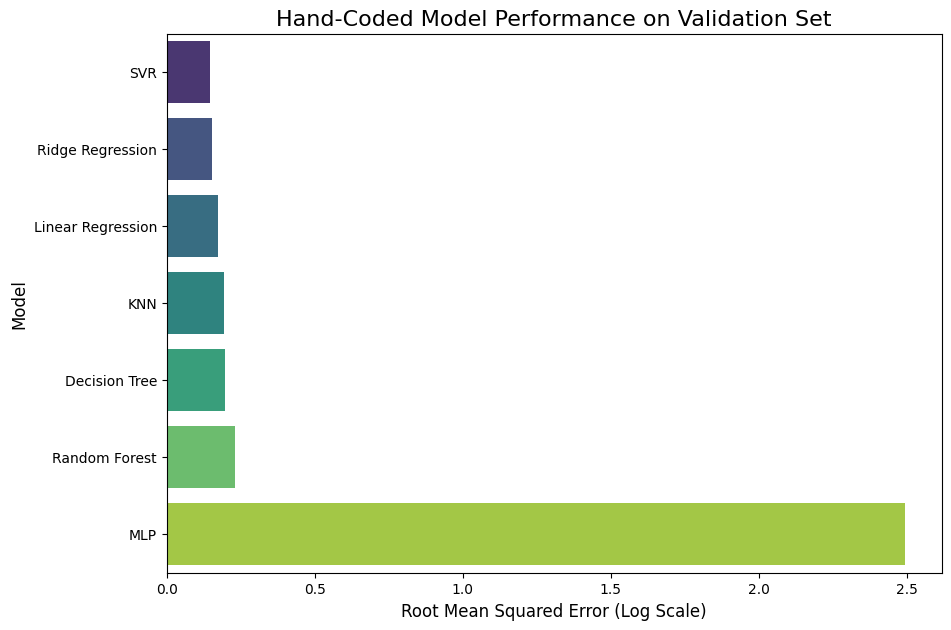

In [5]:
# ...existing code...
# Cell 6: Model Training and Evaluation (REVISED & FIXED)

from sklearn.metrics import mean_squared_error
import time

# Dictionary để lưu kết quả
results = {}
y_train_values = y_train.values

# --- Huấn luyện các model ---
print("\n--- Training Models ---")

# 1. Linear Regression
print("Training Linear Regression...")
lr = HandCodedLinearRegression(fit_intercept=True)
lr.fit(X_train_scaled, y_train_values)
y_pred_lr = lr.predict(X_val_scaled)
results['Linear Regression'] = np.sqrt(mean_squared_error(y_val, y_pred_lr))

# 2. Ridge Regression
print("Training Ridge Regression...")
ridge = HandCodedRidgeRegression(alpha=15.0, fit_intercept=True)
ridge.fit(X_train_scaled, y_train_values)
y_pred_ridge = ridge.predict(X_val_scaled)
results['Ridge Regression'] = np.sqrt(mean_squared_error(y_val, y_pred_ridge))

# 3. Decision Tree
print("Training Decision Tree...")
dt = HandCodedDecisionTreeRegressor(max_depth=7, min_samples_split=10)
dt.fit(X_train.values, y_train_values)
y_pred_dt = dt.predict(X_val.values)
results['Decision Tree'] = np.sqrt(mean_squared_error(y_val, y_pred_dt))

# 4. Random Forest
print("Training Random Forest...")
rf = HandCodedRandomForestRegressor(n_estimators=100, max_depth=10, max_features='sqrt', random_state=42)
rf.fit(X_train.values, y_train_values)
y_pred_rf = rf.predict(X_val.values)
results['Random Forest'] = np.sqrt(mean_squared_error(y_val, y_pred_rf))

# 5. KNN
print("Training KNN Regressor...")
knn = HandCodedKNNRegressor(n_neighbors=7, metric='manhattan')
knn.fit(X_train_scaled, y_train_values)
y_pred_knn = knn.predict(X_val_scaled)
results['KNN'] = np.sqrt(mean_squared_error(y_val, y_pred_knn))

# 6. SVR
print("Training SVR...")
svr = HandCodedSVR(C=0.8, epsilon=0.1, learning_rate=0.0001, n_iters=2000) 
svr.fit(X_train_scaled, y_train_values)
y_pred_svr = svr.predict(X_val_scaled)
if np.isnan(y_pred_svr).any() or np.isinf(y_pred_svr).any():
    print("Warning: SVR predictions contain NaN/Inf values! Skipping.")
else:
    results['SVR'] = np.sqrt(mean_squared_error(y_val, y_pred_svr))

# 7. MLP
print("Training MLP Regressor...")
mlp = HandCodedMLPRegressor(hidden_layer_sizes=(100, 50), n_iters=150, learning_rate=0.001, activation='relu', random_state=42)
mlp.fit(X_train_scaled, y_train_values)
y_pred_mlp = mlp.predict(X_val_scaled)
if np.isnan(y_pred_mlp).any() or np.isinf(y_pred_mlp).any():
    print("Warning: MLP predictions contain NaN/Inf values! Skipping.")
else:
    results['MLP'] = np.sqrt(mean_squared_error(y_val, y_pred_mlp))


# --- In kết quả ---
print("\n--- Model Performance (Validation RMSE) ---")
if not results:
    print("No models were successfully trained.")
else:
    results_df = pd.DataFrame(list(results.items()), columns=['Model', 'RMSE']).sort_values('RMSE')
    print(results_df)

    # Visualize results
    plt.figure(figsize=(10, 7))
    sns.barplot(x='RMSE', y='Model', data=results_df, palette='viridis')
    plt.title('Hand-Coded Model Performance on Validation Set', fontsize=16)
    plt.xlabel('Root Mean Squared Error (Log Scale)', fontsize=12)
    plt.ylabel('Model', fontsize=12)
    plt.show()
# ...existing code...